# Geospatial validation and mapping

[Run in browser](https://muzammilafroz.github.io/applied-economics-data-learning-lab/lab/index.html?path=lessons/02_geospatial_validation_mapping.ipynb) | [Open in Colab](https://colab.research.google.com/github/muzammilafroz/applied-economics-data-learning-lab/blob/main/notebooks/lessons/02_geospatial_validation_mapping.ipynb) | [Course home](https://muzammilafroz.github.io/applied-economics-data-learning-lab/) | [Take the test](https://muzammilafroz.github.io/applied-economics-data-learning-lab/tests/?module=module-02)

> This independent learning resource uses fictional, synthetic data. It is not an official assessment or credential.

## Why this lesson matters

A map is a data product, not decoration. Its key, coordinate system, classification, layer order, and legend can all change what a reader concludes.

Prerequisite: Lesson 1. You will validate geometry joins, preserve repeated coordinates, build Fisher-Jenks classes, and inspect a readable map.

In [1]:
from __future__ import annotations

import os
import sys
import types
from urllib.request import urlopen

if sys.platform == "emscripten":
    import piplite
    await piplite.install("pyodide-http")
    import pyodide_http
    pyodide_http.patch_all()

RAW_CODE_ROOT = "https://raw.githubusercontent.com/muzammilafroz/applied-economics-data-learning-lab/v1.0.0/learning_lab"
if sys.platform == "emscripten":
    from js import window
    if window.location.hostname in {"127.0.0.1", "localhost"}:
        RAW_CODE_ROOT = f"{window.location.origin}/learning_lab"
        os.environ["LEARNING_LAB_DATA_BASE"] = f"{window.location.origin}/data/teaching"

def load_public_module(module_name):
    """Import locally, or fetch the small public helper when running in Colab/Lite."""
    try:
        return __import__(f"learning_lab.{module_name}", fromlist=[module_name])
    except ModuleNotFoundError:
        location = f"{RAW_CODE_ROOT}/{module_name}.py"
        source = urlopen(location).read().decode("utf-8")
        module = types.ModuleType(f"learning_lab.{module_name}")
        exec(compile(source, location, "exec"), module.__dict__)
        return module

lab_io = load_public_module("io")
get_data_url = lab_io.get_data_url
read_teaching_csv = lab_io.read_teaching_csv
read_teaching_geojson = lab_io.read_teaching_geojson

print("Runtime:", sys.platform)
print("Data reference:", os.getenv("LEARNING_LAB_DATA_REF", "v1.0.0"))

Runtime: win32
Data reference: v1.0.0


In [2]:
import geopandas as gpd
if sys.platform == "emscripten":
    await piplite.install("mapclassify")
import mapclassify
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

districts = read_teaching_geojson()
production = read_teaching_csv("district_production.csv")
points = read_teaching_csv("survey_points.csv")

print("Geometry types:", districts.geometry.geom_type.value_counts().to_dict())
print("CRS:", districts.crs)

Geometry types: {'Polygon': 25}
CRS: EPSG:4326


## Geometry and coordinate reference systems

A GeoDataFrame is a pandas table with a geometry column and a coordinate reference system, or CRS. EPSG:4326 stores longitude and latitude in angular degrees. It is suitable here for displaying the fictional teaching map. For accurate distance or area, reproject to an appropriate local projected CRS first.

In [3]:
assert districts.crs.to_string() == "EPSG:4326"
assert districts.geometry.notna().all()
assert districts.geometry.is_valid.all()
assert districts["d"].is_unique
print("Geometry, CRS, and key checks passed.")

Geometry, CRS, and key checks passed.


## Join by the unique code

The name `Riverbend` occurs twice. Joining on that name would create an ambiguous many-to-many relationship. Joining on `d` preserves one geometry and one production value per district.

In [4]:
mapped = districts.merge(production, on="d", validate="one_to_one")
assert len(mapped) == len(districts) == len(production)
assert mapped["production"].notna().all()

display(mapped.loc[mapped["district_name"].eq("Riverbend"), ["d", "district_name", "production"]])

,d,district_name,production
6,7,Riverbend,1605
17,18,Riverbend,12070


## Why Fisher-Jenks here

Production is deliberately skewed. Equal-width bins can crowd many districts into the lowest class. Quantiles put similar numbers of districts in each class but can separate nearly equal values. Fisher-Jenks searches for breaks that make values within each class relatively similar and classes relatively distinct.

This is a data-dependent descriptive choice, not a universal best method. Always report the classifier and inspect the break values.

In [5]:
classifier = mapclassify.FisherJenks(mapped["production"], k=5)
mapped["production_class"] = classifier.yb

print("Class upper bounds:", classifier.bins.tolist())
print("Districts per class:", pd.Series(classifier.yb).value_counts().sort_index().to_dict())
assert len(classifier.bins) == 5

Class upper bounds: [3517.0, 8202.0, 13513.0, 18512.0, 24458.0]
Districts per class: {0: 10, 1: 5, 2: 4, 3: 3, 4: 3}


C:\Users\user\Downloads\applied-economics-data-learning-lab\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3775: UserWarning: Numba not installed. Using slow pure python version.
  exec(code_obj, self.user_global_ns, self.user_ns)


## Repeated coordinates are information

Some point rows deliberately share exactly the same coordinates. That can represent multiple records at one site. Dropping duplicates would change group counts. Jittering the stored values would corrupt the data. We keep every row and diagnose overlap explicitly.

In [6]:
coordinate_counts = (
    points.groupby(["longitude", "latitude"], as_index=False)
    .size()
    .sort_values("size", ascending=False)
)
repeated_pairs = coordinate_counts.loc[coordinate_counts["size"].gt(1)]
repeated_rows = points.duplicated(["longitude", "latitude"], keep=False)

display(repeated_pairs)
print("Rows belonging to repeated pairs:", int(repeated_rows.sum()))
assert points["point_id"].is_unique

,longitude,latitude,size
23,31.747424,0.125594,2
10,30.703069,-1.255664,2
44,33.149534,0.824683,2
51,33.512262,2.138972,2
63,34.415061,2.811021,2
58,33.724606,1.058683,2


Rows belonging to repeated pairs: 12


## Build the map in layers

The polygons form the base. Points are drawn afterward so they remain visible. A white edge separates districts. The legends occupy reserved space to the right, outside the data axes. Point coordinates remain unchanged.

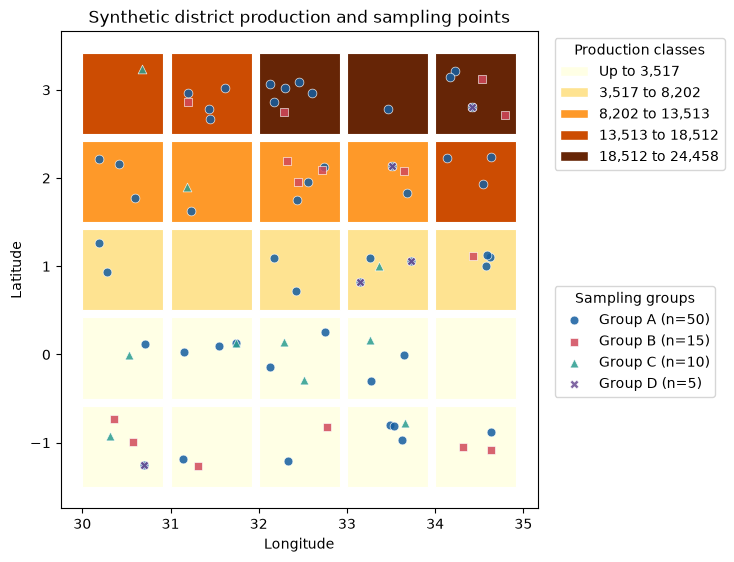

In [7]:
fig, ax = plt.subplots(figsize=(11, 6.2))
class_cmap = plt.get_cmap("YlOrBr", 5)
mapped.plot(
    column="production_class",
    categorical=True,
    cmap=class_cmap,
    linewidth=0.8,
    edgecolor="white",
    ax=ax,
)

markers = {"A": "o", "B": "s", "C": "^", "D": "X"}
colors = {"A": "#145DA0", "B": "#D1495B", "C": "#2A9D8F", "D": "#6A4C93"}
for group, group_points in points.groupby("group", sort=True):
    ax.scatter(
        group_points["longitude"],
        group_points["latitude"],
        label=f"Group {group} (n={len(group_points)})",
        marker=markers[group],
        color=colors[group],
        edgecolor="white",
        linewidth=0.5,
        s=40,
        alpha=0.85,
    )

handles, labels = ax.get_legend_handles_labels()
group_legend = ax.legend(handles, labels, title="Sampling groups", loc="upper left", bbox_to_anchor=(1.02, 0.48))
class_labels = [f"Up to {classifier.bins[0]:,.0f}"] + [
    f"{classifier.bins[index - 1]:,.0f} to {classifier.bins[index]:,.0f}"
    for index in range(1, 5)
]
class_handles = [Patch(facecolor=class_cmap(index), edgecolor="white", label=label) for index, label in enumerate(class_labels)]
class_legend = ax.legend(class_handles, class_labels, title="Production classes", loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.add_artist(group_legend)
ax.set(title="Synthetic district production and sampling points", xlabel="Longitude", ylabel="Latitude")
ax.set_aspect("equal")
fig.subplots_adjust(right=0.68)
plt.show()

## Visual validation checklist

After saving a figure, open the exact saved file. Check that every district is visible, symbols are distinguishable, legends do not cover data, labels are not clipped, colors have enough contrast, and the title says the data are synthetic.

Common failure: a plot can execute without error and still be unusable. File existence proves only that bytes were written.

Guided practice: compare `mapclassify.Quantiles` and `mapclassify.EqualInterval` on the same production column. Record how their break values and class counts differ. Then return to Fisher-Jenks for the module test.